In [7]:
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process.kernels import Matern

In [8]:
#Function 4
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 4.csv') 
columns = ['Input 1', 'Input 2','Input 3', 'Input 4', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
data

,Input 1,Input 2,Input 3,Input 4,Outputs
0,0.896981,0.725628,0.175404,0.701694,-22.108290
1,0.889356,0.499588,0.539269,0.508783,-14.601400
2,0.250946,0.033693,0.145380,0.494932,-11.699930
3,0.346962,0.006250,0.760564,0.613024,-16.053770
4,0.124871,0.129770,0.384400,0.287076,-10.069630
5,0.801303,0.500231,0.706645,0.195103,-15.487080
6,0.247708,0.060445,0.042186,0.441324,-12.681690
7,0.746702,0.757092,0.369353,0.206566,-16.026400
8,0.400665,0.072574,0.886768,0.243842,-17.049240
9,0.626071,0.586751,0.438806,0.778858,-12.741770


In [9]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3', 'Input 4']])
Y = np.array(data[['Outputs']])


In [10]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Input 4,Outputs
Input 1,1.000000,0.306584,0.137471,0.076046,-0.329013
Input 2,0.306584,1.000000,-0.139156,0.100647,-0.290691
Input 3,0.137471,-0.139156,1.000000,-0.037106,-0.219726
Input 4,0.076046,0.100647,-0.037106,1.000000,-0.563766
Outputs,-0.329013,-0.290691,-0.219726,-0.563766,1.000000


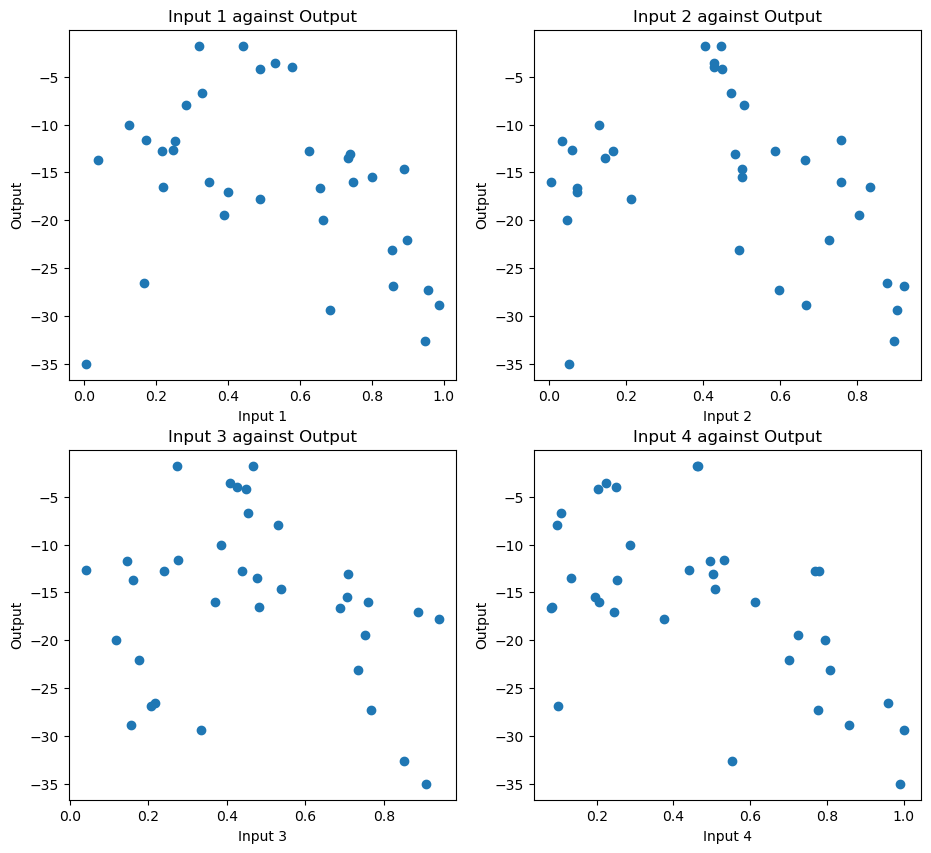

In [11]:
#Plotting each Input against the output
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,2, figsize = (11,10))

ax[0][0].scatter(X[:,0], Y)
ax[0][1].scatter(X[:,1], Y)
ax[1][0].scatter(X[:,2], Y)
ax[1][1].scatter(X[:,3], Y)

#Creating titles and axis labels
ax[0][0].set_title('Input 1 against Output')
ax[0][1].set_title('Input 2 against Output')
ax[1][0].set_title('Input 3 against Output')
ax[1][1].set_title('Input 4 against Output')

ax[0][0].set_xlabel('Input 1')
ax[0][0].set_ylabel('Output')

ax[0][1].set_xlabel('Input 2')
ax[0][1].set_ylabel('Output')

ax[1][0].set_xlabel('Input 3')
ax[1][0].set_ylabel('Output')

ax[1][1].set_xlabel('Input 4')
ax[1][1].set_ylabel('Output')

plt.show()

In [12]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp_best = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
gp_best.fit(X,Y)
#Use latin hypercube sampling to create a set of candidate points 
d = 4
n = 100000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Fit the GP regressor to the candidate points
mu, std = gp_best.predict(grid, return_std = True)

In [13]:
#Calculating expected improvement
best_y = np.max(Y)
eta = 0.01
z = (mu - best_y - eta) / (std + 1e-12)
ei = (mu - best_y - eta ) * norm.cdf(z) + std * norm.pdf(z)
#Find Candidate value that maximises expected improvement 
best_idx = np.argmax(ei)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.412758, 0.417401, 0.380804, 0.418898])

In [22]:
#Calculate UCB as comparison
beta = 3 #set exploration parameter
UCB = mu + beta * std
best_idx = np.argmax(UCB)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.448159, 0.518735, 0.367877, 0.410965])